In [36]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from numpy.linalg import eig
from datetime import datetime, timedelta
from sklearn.decomposition import PCA

In [37]:
sectors = ['energy', 'materials', 'industrials', 'consumer_discretionary',\
           'consumer_staples', 'health_care', 'financials', 'information_technology',\
           'communication_services', 'utilities', 'real_estate']

models = ['gpt-3.5-turbo-0613', 'gpt-4', 'gpt-4-1106-preview', 'bard', 'claude']

## HHI

In [38]:
def calculate_hhi(sector_name, portfolio):
    squared_weights = portfolio['Weight'].apply(lambda x: x**2)
    return squared_weights.sum()

In [39]:
for model in models:
    for sector_name in sectors:
        if model == 'gpt-4':
            csv_path = f'cached/4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == "gpt-4-1106-preview":
            csv_path = f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_path = f'cached/bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'claude':
            csv_path = f'cached/claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_path = f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_path)
        index = calculate_hhi(sector_name, portfolio)

        with open('metrics/hhi.csv', 'a', encoding='utf-8') as f:
            f.write(f'{model},{sector_name},{index}\n')
    

$$
HHI = \sum_{i=1}^n s_i^2
$$

The bigger the index, the less difersified the portfolio is (more weight is assigned to particular companies). In my case, I am using the decimal numbers.

Examples in my case:

- one asset with 100% weught: HHI = 100
- 15 equally weighted assets: HHI = 6.67

In [40]:
df = pd.read_csv('metrics/hhi.csv')
df['index'] *= 100
df.sort_values(by='index')

,model,sector,index
123,gpt-4,industrials,6.838862
68,gpt-4,industrials,6.838862
13,gpt-4,industrials,6.838862
24,gpt-4-1106-preview,industrials,6.847929
79,gpt-4-1106-preview,industrials,6.847929
...,...,...,...
157,claude,consumer_discretionary,12.899421
47,claude,consumer_discretionary,12.899421
161,claude,information_technology,14.668648
106,claude,information_technology,14.668648


## PCA

In [41]:
def perform_pca(sector_name, alpha=0):
    cevs = []

    for model in models:
        if model == 'gpt-4':
            csv_path = f'cached/4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == "gpt-4-1106-preview":
            csv_path = f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_path =  f'cached/bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'claude':
            csv_path =  f'cached/claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_path = f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_path)

        csv_path = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_out = pd.read_csv(csv_path)
        required_columns = portfolio['Stock'].tolist()
        returns_out_filtered = returns_out.loc[:, required_columns]
        
        print(f'Processing {sector_name.upper()} sector, {model.upper()} model portfolio')

        pca = PCA()
        pca.fit(returns_out_filtered)

        explained_variance_ratio = pca.explained_variance_ratio_
        print('Explained variance ratio: ', explained_variance_ratio)
        
        cumulative_explained_variance = np.cumsum(explained_variance_ratio)
        cevs.append(cumulative_explained_variance)

    plt.figure(figsize=(8, 6))

    for i, cumulative_explained_variance in enumerate(cevs):
        plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', label=models[i])

    plt.axhline(y=alpha, color='red', linestyle='--')

    plt.xlabel('Number of principal components')
    plt.ylabel('Cumulative explained variance ratio')
    plt.title(f'{sector_name} sector portfolio')
    plt.legend(models, loc='lower right')
    plt.show()



Processing ENERGY sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.65945192 0.09883558 0.05852572 0.03560373 0.02625975 0.02126954
 0.01770261 0.01671781 0.014542   0.01338656 0.01030661 0.00893876
 0.00742014 0.00671678 0.00432245]
Processing ENERGY sector, GPT-4 model portfolio
Explained variance ratio:  [0.66914563 0.09524361 0.05747254 0.0338416  0.02604796 0.02075669
 0.01745532 0.01490724 0.01339231 0.0118467  0.00982753 0.0087155
 0.00821054 0.00702792 0.0061089 ]
Processing ENERGY sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.66973987 0.09488139 0.05574981 0.0349229  0.026994   0.0209206
 0.0171669  0.01618232 0.01367061 0.0133343  0.00978832 0.00867537
 0.00730379 0.00638112 0.00428868]
Processing ENERGY sector, BARD model portfolio
Explained variance ratio:  [0.67942814 0.09082408 0.04852387 0.03411018 0.03147009 0.01967049
 0.01933005 0.01392253 0.01268158 0.01119168 0.00972232 0.00895655
 0.00777553 0.00671297 0.00567994]
P

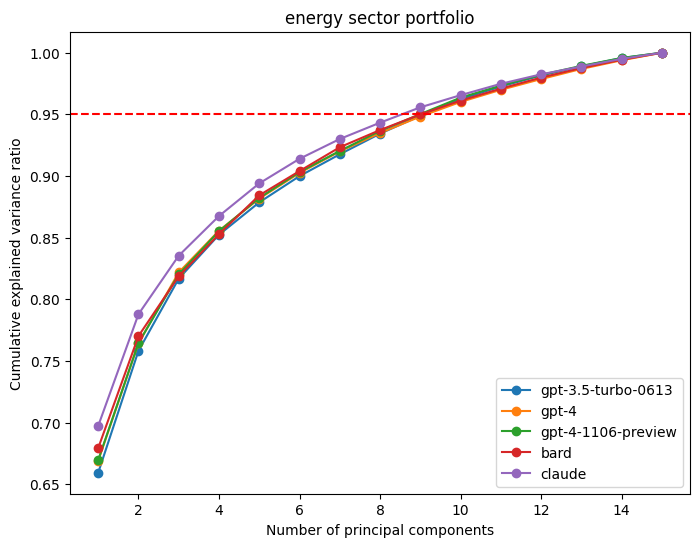

Processing MATERIALS sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.40360683 0.13118075 0.10269986 0.07731353 0.06788352 0.04547432
 0.03942588 0.0295331  0.02655478 0.02294715 0.01827945 0.01142871
 0.01043635 0.00853569 0.00470005]
Processing MATERIALS sector, GPT-4 model portfolio
Explained variance ratio:  [0.43322534 0.13790153 0.09151268 0.07100973 0.05125131 0.0456475
 0.03473518 0.02958702 0.02346611 0.01955185 0.01782571 0.01335865
 0.01207731 0.0105575  0.00829257]
Processing MATERIALS sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.41259409 0.12750291 0.09563049 0.07561091 0.06629032 0.04415786
 0.04067826 0.0316478  0.02718231 0.02085394 0.01783938 0.01244704
 0.0106351  0.00885988 0.0080697 ]
Processing MATERIALS sector, BARD model portfolio
Explained variance ratio:  [0.42419999 0.11662612 0.09426045 0.0813875  0.04673184 0.04559083
 0.04003375 0.03455588 0.03064841 0.0240477  0.02062523 0.01528046
 0.0111139  0.00959301 

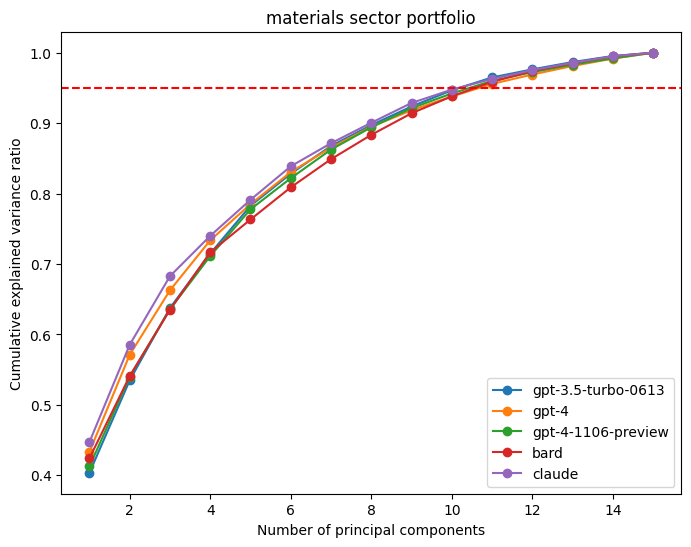

Processing INDUSTRIALS sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.42152968 0.10263318 0.08873151 0.06186984 0.05141967 0.04410209
 0.04232953 0.03350997 0.02981175 0.02811729 0.02261875 0.02220314
 0.01896564 0.01771175 0.01444621]
Processing INDUSTRIALS sector, GPT-4 model portfolio
Explained variance ratio:  [0.40216342 0.11674137 0.09535073 0.06014616 0.05815637 0.04946877
 0.04234324 0.03346022 0.03015613 0.02687245 0.02245942 0.02180382
 0.01874272 0.01474815 0.00738704]
Processing INDUSTRIALS sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.40864857 0.12209061 0.08960378 0.06269702 0.05947611 0.04674837
 0.03917481 0.03236108 0.0311524  0.02583174 0.02432054 0.02141898
 0.01669432 0.01207029 0.00771138]
Processing INDUSTRIALS sector, BARD model portfolio
Explained variance ratio:  [0.3821002  0.0980733  0.09400072 0.07458739 0.06987101 0.05615359
 0.04413664 0.03495131 0.03055763 0.02940142 0.0274847  0.022956
 0.01818338 0.01

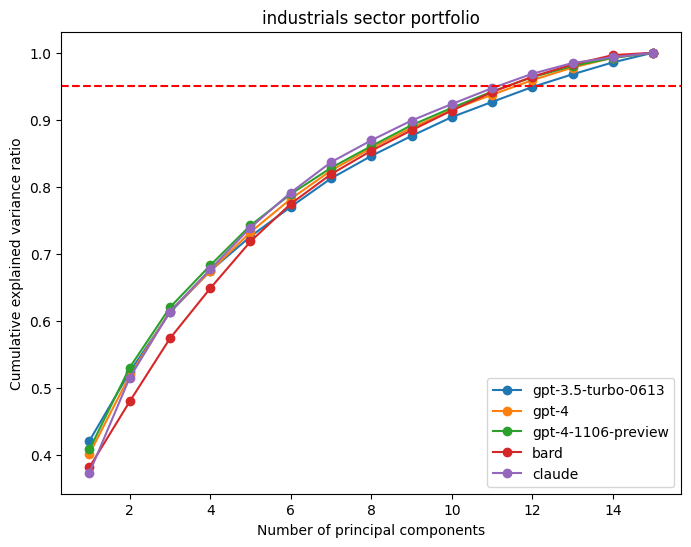

Processing CONSUMER_DISCRETIONARY sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.41083507 0.13361489 0.11786166 0.08762899 0.05476503 0.04328139
 0.03570262 0.02967447 0.0229243  0.02155146 0.01756914 0.01106994
 0.00515365 0.00435647 0.00401092]
Processing CONSUMER_DISCRETIONARY sector, GPT-4 model portfolio
Explained variance ratio:  [0.34175204 0.15851296 0.13670401 0.07001996 0.05676591 0.05295321
 0.03548939 0.03288107 0.03173667 0.02818221 0.02080339 0.01439304
 0.00894097 0.00586762 0.00499753]
Processing CONSUMER_DISCRETIONARY sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.36908988 0.15632308 0.13443902 0.06558179 0.05185324 0.04332029
 0.0398465  0.03508515 0.02512112 0.02304394 0.02070381 0.01423056
 0.01052616 0.00587852 0.00495695]
Processing CONSUMER_DISCRETIONARY sector, BARD model portfolio
Explained variance ratio:  [0.38412313 0.12913404 0.11665288 0.08594776 0.0537075  0.04920366
 0.04076281 0.03009327 0.02746947 0.0

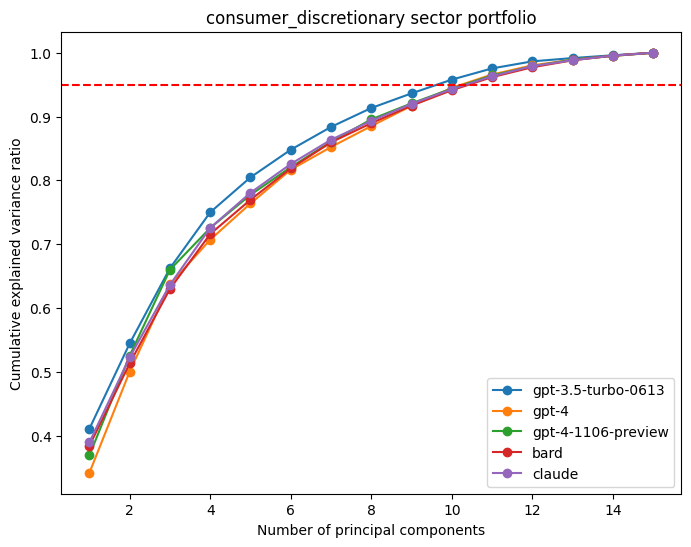

Processing CONSUMER_STAPLES sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.38482839 0.21810928 0.0770957  0.0622753  0.05527351 0.04674763
 0.03166435 0.02739638 0.02226585 0.0184213  0.01509326 0.01374849
 0.01152716 0.00940969 0.00614371]
Processing CONSUMER_STAPLES sector, GPT-4 model portfolio
Explained variance ratio:  [0.35897619 0.20866181 0.13343172 0.06211071 0.05174125 0.03738035
 0.03297626 0.02223026 0.02080937 0.0175561  0.01496557 0.01281608
 0.01145632 0.00875446 0.00613356]
Processing CONSUMER_STAPLES sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.3939137  0.24321413 0.06900802 0.06039559 0.05164563 0.03677243
 0.0303732  0.02368801 0.02062649 0.01716275 0.01445363 0.01225194
 0.01108353 0.00942963 0.00598132]
Processing CONSUMER_STAPLES sector, BARD model portfolio
Explained variance ratio:  [0.38405747 0.10883191 0.09797537 0.06753543 0.06039653 0.05463581
 0.04769829 0.04134511 0.03614903 0.02557239 0.02205538 0.018

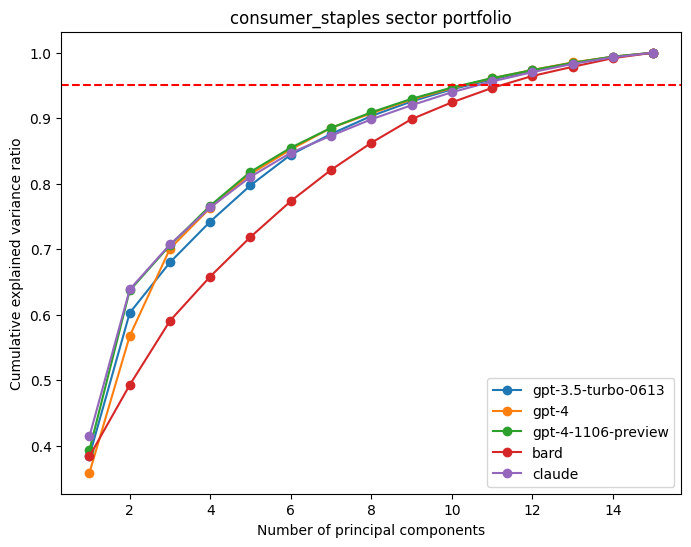

Processing HEALTH_CARE sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.28527837 0.14448053 0.08898924 0.0792388  0.06261461 0.05681115
 0.05242958 0.04346195 0.03851055 0.03470091 0.02918707 0.02502365
 0.02265601 0.01968071 0.01693689]
Processing HEALTH_CARE sector, GPT-4 model portfolio
Explained variance ratio:  [0.27315205 0.15972368 0.1114837  0.09864886 0.06026786 0.04903064
 0.04179442 0.03741976 0.03394843 0.03234795 0.02598695 0.02474153
 0.02021196 0.01810032 0.01314188]
Processing HEALTH_CARE sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.2644758  0.15718385 0.12865527 0.09419638 0.05718207 0.05260005
 0.04635462 0.04005733 0.03307763 0.03014292 0.026026   0.0231595
 0.01786066 0.01621442 0.01281351]
Processing HEALTH_CARE sector, BARD model portfolio
Explained variance ratio:  [0.29760538 0.15130812 0.10492688 0.08428978 0.07998851 0.04988839
 0.0434015  0.03814308 0.03219243 0.02857742 0.0235493  0.02039218
 0.01773097 0.0

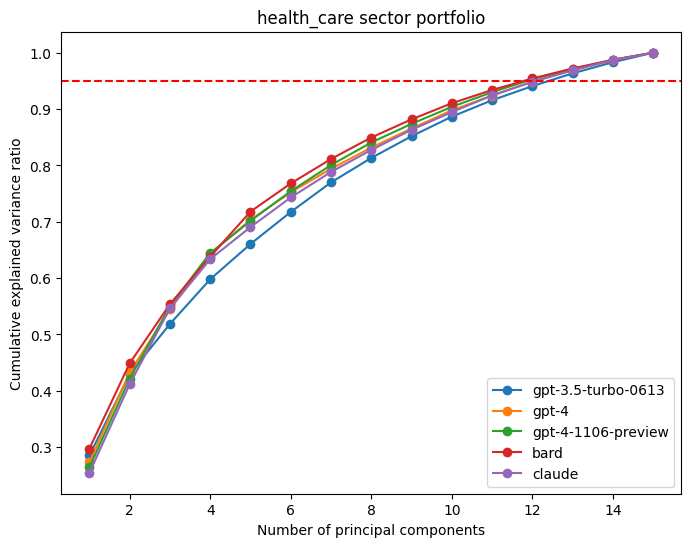

Processing FINANCIALS sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.55721688 0.11259154 0.06924927 0.0671076  0.0407488  0.0382151
 0.02805003 0.01694151 0.01654726 0.01266595 0.01234915 0.00930555
 0.0080328  0.00660419 0.00437438]
Processing FINANCIALS sector, GPT-4 model portfolio
Explained variance ratio:  [0.57847088 0.11168252 0.0722437  0.05477667 0.04132782 0.02738955
 0.02486496 0.01871054 0.0174035  0.01388441 0.01077716 0.00967265
 0.00777297 0.00642494 0.00459771]
Processing FINANCIALS sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.55782434 0.11208688 0.08014062 0.05668741 0.04101172 0.02850561
 0.02578769 0.02165475 0.01845918 0.01513953 0.01246274 0.01019346
 0.00871603 0.00668213 0.00464789]
Processing FINANCIALS sector, BARD model portfolio
Explained variance ratio:  [0.53760984 0.13730606 0.07016416 0.05973916 0.05197932 0.03385692
 0.02341679 0.02244669 0.01571297 0.01184186 0.01005379 0.00821284
 0.00776939 0.00521

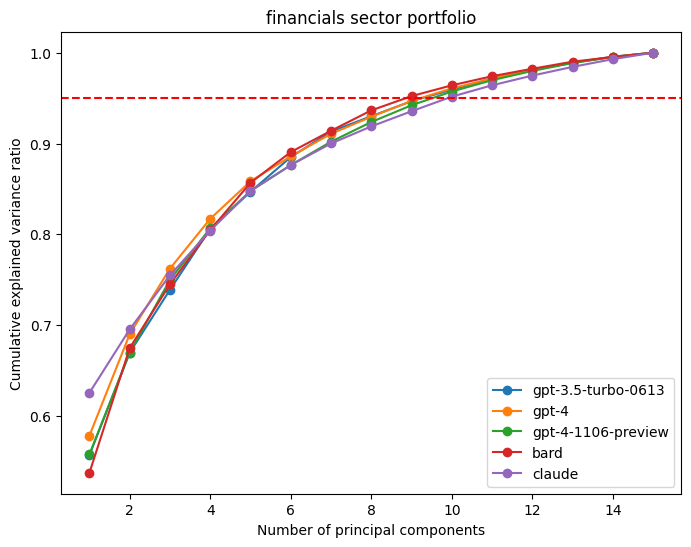

Processing INFORMATION_TECHNOLOGY sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.49887447 0.11194669 0.06761486 0.06330239 0.04708809 0.03980959
 0.03540902 0.03023679 0.02351195 0.02146766 0.01902677 0.01308359
 0.01289017 0.00916415 0.00657381]
Processing INFORMATION_TECHNOLOGY sector, GPT-4 model portfolio
Explained variance ratio:  [0.47933717 0.12067581 0.07210528 0.05751514 0.04878634 0.04007336
 0.03600633 0.02824877 0.02387732 0.02075611 0.02026647 0.01824309
 0.01392093 0.01150239 0.0086855 ]
Processing INFORMATION_TECHNOLOGY sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.47933717 0.12067581 0.07210528 0.05751514 0.04878634 0.04007336
 0.03600633 0.02824877 0.02387732 0.02075611 0.02026647 0.01824309
 0.01392093 0.01150239 0.0086855 ]
Processing INFORMATION_TECHNOLOGY sector, BARD model portfolio
Explained variance ratio:  [0.40255053 0.1295533  0.09954966 0.07453817 0.06382465 0.04005898
 0.03710643 0.02802732 0.02728754 0.0

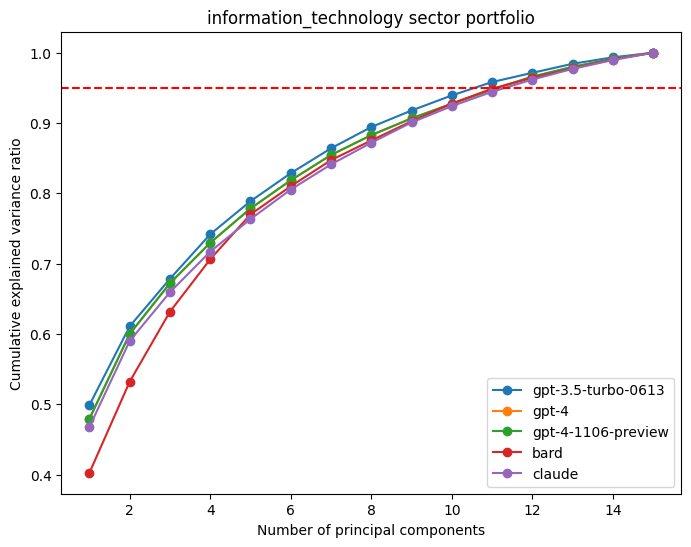

Processing COMMUNICATION_SERVICES sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [3.22045720e-01 1.42959071e-01 1.29262458e-01 1.04495774e-01
 7.81342053e-02 5.92131111e-02 4.67474784e-02 4.11549799e-02
 2.73445126e-02 1.74773462e-02 1.66011787e-02 1.44039291e-02
 1.60235522e-04]
Processing COMMUNICATION_SERVICES sector, GPT-4 model portfolio
Explained variance ratio:  [2.99413200e-01 1.45857889e-01 1.33209939e-01 1.03989740e-01
 6.31019573e-02 5.65318138e-02 4.81017444e-02 3.83422127e-02
 2.68375299e-02 2.53539759e-02 1.67528891e-02 1.64747844e-02
 1.41457234e-02 1.17313031e-02 1.55297170e-04]
Processing COMMUNICATION_SERVICES sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.29449596 0.13484163 0.11851061 0.1044892  0.08961022 0.05557903
 0.04991195 0.04072355 0.03009556 0.02539746 0.01633816 0.01552491
 0.01349988 0.01098186]
Processing COMMUNICATION_SERVICES sector, BARD model portfolio
Explained variance ratio:  [3.16905389e-01 1.50478

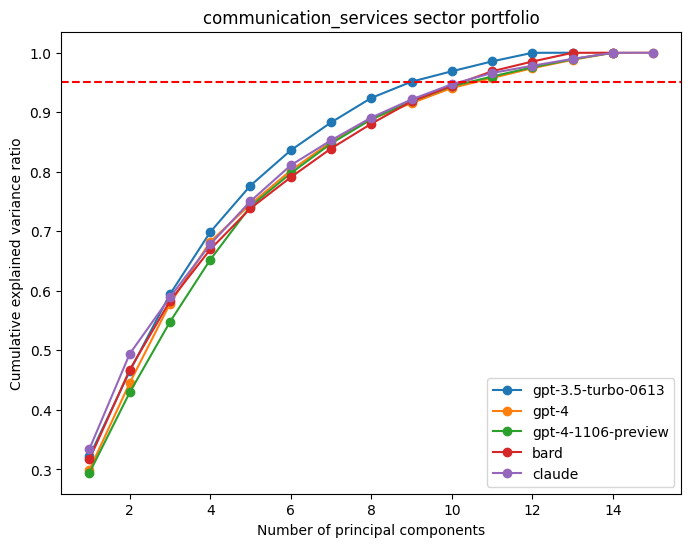

Processing UTILITIES sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.74398717 0.06519552 0.04899066 0.02283389 0.01822897 0.01568861
 0.01429828 0.01333128 0.01190903 0.00977725 0.0086151  0.00828038
 0.00785685 0.00684878 0.00415823]
Processing UTILITIES sector, GPT-4 model portfolio
Explained variance ratio:  [0.73632691 0.06374324 0.04905047 0.02224942 0.02165372 0.01799341
 0.01591793 0.01394281 0.01168591 0.0106072  0.00911418 0.00811455
 0.00702158 0.00680311 0.00577556]
Processing UTILITIES sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.74159088 0.06700798 0.04414121 0.02379239 0.018514   0.01697944
 0.0149993  0.01307555 0.01290839 0.01033197 0.00851493 0.00776337
 0.00749474 0.00711715 0.00576868]
Processing UTILITIES sector, BARD model portfolio
Explained variance ratio:  [0.63135794 0.09616101 0.07675093 0.0483521  0.03266267 0.02574059
 0.02322646 0.01136904 0.0108855  0.00997884 0.00802488 0.0076882
 0.00648246 0.00583359 

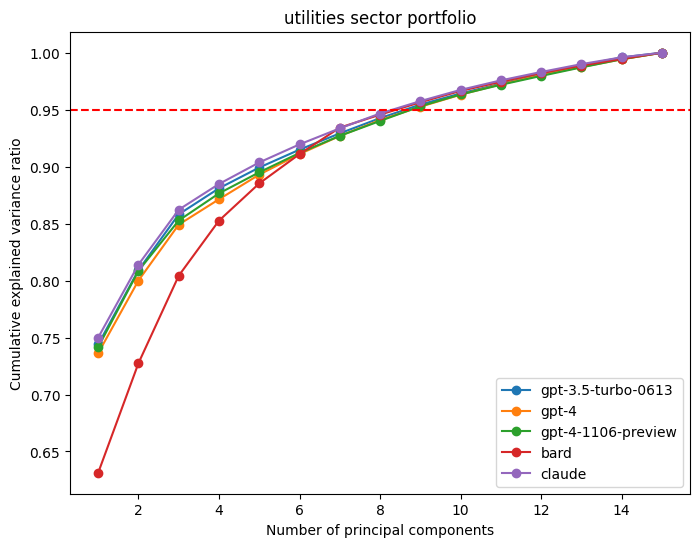

Processing REAL_ESTATE sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.5860948  0.0788022  0.07407066 0.05786992 0.04359787 0.03015636
 0.02496267 0.02068974 0.01656235 0.01535699 0.01397955 0.01302573
 0.01140032 0.00834657 0.00508427]
Processing REAL_ESTATE sector, GPT-4 model portfolio
Explained variance ratio:  [0.58750288 0.08329396 0.06419478 0.05293616 0.04128432 0.03581827
 0.0260954  0.02249929 0.0178084  0.01636237 0.01530907 0.01527364
 0.01231478 0.00661876 0.00268793]
Processing REAL_ESTATE sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.57662711 0.08195725 0.06446687 0.04615332 0.04124014 0.03226351
 0.03117984 0.02405204 0.02171925 0.01891946 0.01735241 0.01550907
 0.01335612 0.01229297 0.00291065]
Processing REAL_ESTATE sector, BARD model portfolio
Explained variance ratio:  [0.58802876 0.08710348 0.06467087 0.05412009 0.04589208 0.0277307
 0.02444514 0.0208593  0.01986499 0.01747285 0.01641925 0.01276897
 0.01063791 0.0

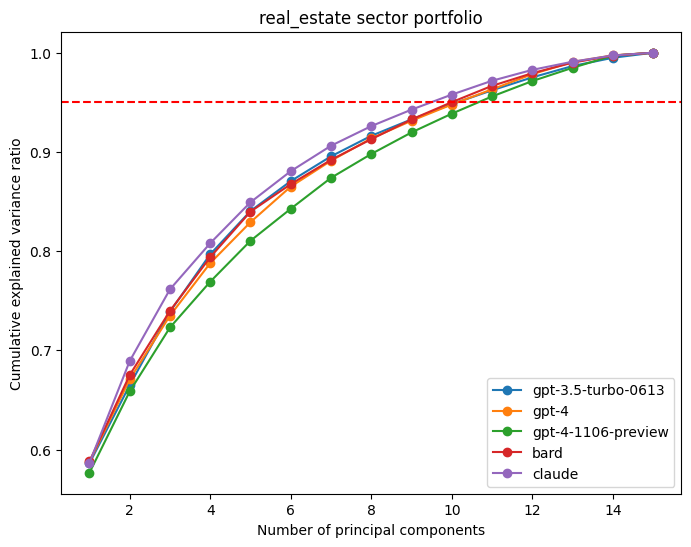

In [42]:
for sector_name in sectors:
    perform_pca(sector_name, 0.95)

## Volatility

In [43]:
df = pd.read_csv('metrics/portfolio_volatilities.csv')
df.sort_values(by='volatility')

,model,sector,volatility
214,GPT4preview,health_care,0.00386
134,GPT4preview,health_care,0.00386
74,GPT4preview,health_care,0.00386
133,GPT4,health_care,0.00401
213,GPT4,health_care,0.00401
...,...,...,...
187,claude,information_technology,0.02010
227,claude,information_technology,0.02010
35,bard,information_technology,0.02033
32,GPT4,information_technology,0.02046


In [44]:
temp = df.groupby('sector').sum().sort_values(by='volatility').sort_values(by='volatility')
temp['volatility'] / 5

sector
health_care               0.016188
consumer_staples          0.028600
industrials               0.032272
materials                 0.033648
real_estate               0.037198
utilities                 0.038816
communication_services    0.039054
consumer_discretionary    0.041778
financials                0.049670
energy                    0.069082
information_technology    0.091114
Name: volatility, dtype: float64

## Effective rank of the matrix functions

In [45]:
def erank_function(eigenvalues):
    '''
    e ** H(eigenvalues)
    H is Shannon entropy
    '''
    shannon_entropy_value, n = 0, len(eigenvalues)

    for i, p_i in enumerate(eigenvalues):
        shannon_entropy_value += (p_i * np.log(p_i))

    return np.e ** (-shannon_entropy_value)

In [46]:
def calculate_erank(returns_out_filtered, model, sector_name, write=False):
    returns_covariance_mtx = np.cov(returns_out_filtered)

    eigenvalues = eig(returns_covariance_mtx)[0] # returns eig, eiv
    eigenvalues_st = [(eig/sum(eigenvalues)) for eig in eigenvalues] # standartize
    erank = erank_function(eigenvalues_st)
    
    if write:
        with open('metrics/erank.csv', 'a', encoding='utf-8') as f:
            f.write(f'{model},{sector_name},{np.real(erank)}\n')

    return np.real(erank)

## Calculate effective rank sectorwise

In [47]:
def process_sectors(sector_name):
    print(f'{sector_name.upper()} SECTOR')
    for model in models:
        if model == 'gpt-4':
            csv_path = f'cached/4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == "gpt-4-1106-preview":
            csv_path = f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_path =  f'cached/bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'claude':
            csv_path =  f'cached/claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_path = f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_path)

        csv_path = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_out = pd.read_csv(csv_path)
        required_columns = portfolio['Stock'].tolist()
        returns_out_filtered = returns_out.loc[:, required_columns]


        # EFFECTIVE RANK (NO WEIGHTS, RETURNS COVARIANCES)
        erank = calculate_erank(returns_out_filtered, model, sector_name)
        print('my erank: ', erank)

        with open('metrics/erank.csv', 'a', encoding='utf-8') as f:
            f.write(f'{model},{sector_name},{erank}\n')

        # print(f'Processing {sector_name.upper()} sector, {model.upper()} model portfolio')


When we take one stock, say, CLX 15 times (non diversified portfolio) = rank nan.

When we compose a portfolio out of 14 same stocks and 1 different, for example: CLX 14 times + MO 1 time = rank 0.99.

And so on.

In [48]:
for sector_name in sectors:
    process_sectors(sector_name)

ENERGY SECTOR
my erank:  9.508468974412914
my erank:  9.758390395457317
my erank:  9.607238544598085
my erank:  9.814037024935278
my erank:  9.519154782280822
MATERIALS SECTOR
my erank:  9.72383375071626
my erank:  9.784905336650183
my erank:  9.974864647502214
my erank:  10.411490000692902
my erank:  9.49070402598567
INDUSTRIALS SECTOR
my erank:  11.556798288059607
my erank:  10.94797227657276
my erank:  10.809188154603037
my erank:  10.87841727028904
my erank:  10.43155183607004
CONSUMER_DISCRETIONARY SECTOR
my erank:  8.504144648040947
my erank:  8.957197322395436
my erank:  8.989413733446826
my erank:  9.32190001896318
my erank:  9.056332326046505
CONSUMER_STAPLES SECTOR
my erank:  7.692093484090776
my erank:  7.37438451573772
my erank:  7.295155964692825
my erank:  10.94476780276401
my erank:  6.976784855461902
HEALTH_CARE SECTOR
my erank:  11.503103306756481
my erank:  10.737321150774687
my erank:  10.548387311537473
my erank:  10.232335275433378
my erank:  10.69282315806412
FINA

In [49]:
ranks = pd.read_csv('metrics/erank.csv')
ranks.sort_values(by='effective_rank', ascending=False)

,model,sector,effective_rank
65,gpt-3.5-turbo-0613,industrials,11.556798
10,gpt-3.5-turbo-0613,industrials,11.556798
80,gpt-3.5-turbo-0613,health_care,11.503103
25,gpt-3.5-turbo-0613,health_care,11.503103
52,gpt-4-1106-preview,real_estate,11.129196
...,...,...,...
21,gpt-4,consumer_staples,7.374385
22,gpt-4-1106-preview,consumer_staples,7.295156
77,gpt-4-1106-preview,consumer_staples,7.295156
79,claude,consumer_staples,6.976785


## Sharpe ratio: sector indices

In [50]:
## In-sample end date (using 5 years of weekly data prior to end date)
insample_enddate = datetime(2023, 3, 31)

## Out-of-sample period (1 Apr 2023 to 1 Dec 2023) (using daily data))
outsample_startdate = datetime(2023, 4, 1)
outsample_enddate   = datetime(2023, 12,  1)

insample_startdate = insample_enddate - timedelta(weeks=5*52) # five years prior to April 2023

In [51]:
index_tickers = ["^GSPE", '^SP500-15', '^SP500-20', '^SP500-25', '^SP500-30', '^SP500-35', '^SP500-40',\
                 '^SP500-45', '^SP500-50', '^SP500-55', '^SP500-60']

index_data_outs = pd.DataFrame()

for ticker in index_tickers:
    index_df = yf.download(ticker, start=outsample_startdate, end=outsample_enddate, interval='1d')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_outs[ticker] = index_df['Index_Return']

index_data_outs.index = pd.to_datetime(index_data_outs.index)

valid_index_tickers_outs = []

for ticker in index_tickers:
    if ticker in index_data_outs.columns and index_data_outs[ticker].notna().all():
        valid_index_tickers_outs.append(ticker)


index_tickers = valid_index_tickers_outs

print("Valid Index Tickers in Out-of-Sample Period")
print(valid_index_tickers_outs)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
Valid Index Tickers in Out-of-Sample Period
['^GSPE', '^SP500-15', '^SP500-20', '^SP500-25', '^SP500-30', '^SP500-35', '^SP500-40', '^SP500-45', '^SP500-50', '^SP500-55', '^SP500-60']


In [52]:
index_data_outs

,^GSPE,^SP500-15,^SP500-20,^SP500-25,^SP500-30,^SP500-35,^SP500-40,^SP500-45,^SP500-50,^SP500-55,^SP500-60
Date,,,,,,,,,,,
2023-04-04,-0.017205,-0.014671,-0.022524,-0.000720,-0.002435,0.000236,-0.010124,-0.005819,0.003064,0.005212,0.000859
2023-04-05,0.014207,-0.002223,-0.013005,-0.020381,0.005547,0.017304,-0.001413,-0.011920,-0.002175,0.025721,-0.005064
2023-04-06,-0.014716,-0.002189,-0.000254,0.000496,0.000801,0.002252,0.003074,0.006785,0.017072,0.007355,0.006987
2023-04-10,0.006466,0.004925,0.008976,0.004249,-0.000140,-0.000372,0.002708,-0.001472,-0.006888,-0.002002,0.005097
2023-04-11,0.008916,0.007282,0.005891,0.000159,0.002413,0.002961,0.008495,-0.010330,-0.004264,0.000650,0.004517
...,...,...,...,...,...,...,...,...,...,...,...
2023-11-24,0.004469,0.003326,0.002915,0.001336,0.003824,0.005107,0.003298,-0.003182,-0.006658,0.003042,0.003232
2023-11-27,-0.003968,-0.000844,-0.005792,0.001926,-0.002396,-0.006353,-0.002810,0.000441,-0.004746,0.000948,0.004280
2023-11-28,0.000576,0.001963,-0.002420,0.005379,0.004021,-0.005034,-0.001025,0.001912,0.003263,0.003125,0.005800


In [53]:
risk_free_rate = 0.02
risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1

sharpe_ratios = {}
for column in index_data_outs.columns:
    returns = index_data_outs[column]
    average_return = np.mean(returns)
    std_dev = np.std(returns)
    sharpe_ratio = (average_return - risk_free_rate) / std_dev
    sharpe_ratios[column] = sharpe_ratio

sharpe_df = pd.DataFrame.from_dict(sharpe_ratios, orient='index', columns=['Sharpe Ratio'])
sharpe_df.index.name = 'Index'

print(sharpe_df)

           Sharpe Ratio
Index                  
^GSPE         -1.543767
^SP500-15     -2.052822
^SP500-20     -2.237934
^SP500-25     -1.578508
^SP500-30     -3.210743
^SP500-35     -2.900678
^SP500-40     -2.219730
^SP500-45     -1.591043
^SP500-50     -1.510370
^SP500-55     -1.902658
^SP500-60     -1.722779


In [54]:
sharpe_df.sort_values(by='Sharpe Ratio', ascending=False)

,Sharpe Ratio
Index,
^SP500-50,-1.510370
^GSPE,-1.543767
^SP500-25,-1.578508
^SP500-45,-1.591043
^SP500-60,-1.722779
^SP500-55,-1.902658
^SP500-15,-2.052822
^SP500-40,-2.219730
^SP500-20,-2.237934


In [55]:
for sector_name in sectors:
    for model in models:
        if model == 'gpt-4':
            csv_filename = f'cached/4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-3.5-turbo-0613':
            csv_filename = f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-4-1106-preview':
            csv_filename = f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_filename = f'cached/bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_filename = f'cached/claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_filename)
        stocks_in_portfolio = portfolio['Stock']
        weights = portfolio.sort_values(by='Stock')['Weight']

        csv_filename_returns = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_df = pd.read_csv(csv_filename_returns)
        returns_df = returns_df[stocks_in_portfolio]

        risk_free_rate = 0.02
        risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1  # Convert annual risk-free rate to daily rate

        weighted_returns = returns_df.T * weights
        portfolio_return = weighted_returns.sum(axis=1)

        avg_portfolio_return = np.mean(portfolio_return)
        std_portfolio_return = np.std(portfolio_return)

        # std_portfolio_return = np.sqrt(np.dot(weights, np.dot(np.cov(returns_df), weights)))

        sharpe_ratio = (avg_portfolio_return - risk_free_rate_daily) / std_portfolio_return
        print(sharpe_ratio)

        with open('metrics/sharpe_ratio.csv', 'a', encoding='utf-8') as f:
            f.write(f'{sector_name},{model},{sharpe_ratio}\n')

-0.6550038197883431
-0.5417837533355934
-0.6668268238549508
0.15804665583124902
-0.7213746731583784
-0.4937117201194174
-0.639749584612834
-0.7613707934423439
-0.3874893563884426
-0.4615406057311898
-0.5855393916522962
-0.9858064855348787
-0.6820953339970505
-0.39100951790330135
-0.39987788055822426
-0.5120062126047111
-0.5502953222456559
-0.5102243903836703
-0.6740225009688683
-0.6595123440223083
0.6929227662302387
0.9255079809910043
2.223940945964565
0.5741106102312202
1.641040426928265
0.8884200545326255
0.6780890194896413
0.7098402086847727
0.7688566467224351
0.8831240606281048
0.35495486916332974
-0.18221416028266346
-0.007937878154188765
0.6771171471120572
-0.07910783983533862
-1.3607823178103213
-1.2642869853073877
-1.2812552015507637
-1.3489306771911016
-1.267562984826408
-0.258526695548799
0.14120105391948096
-0.03479481947333739
0.00209531499679889
-0.22362097955431315
3.3171152536855475
5.221946463284934
3.962920998723459
3.808776973569851
4.29491233225396
-0.052508497538348

In [56]:
sh = pd.read_csv('metrics/sharpe_ratio.csv')
sh.sort_values(by='sector')

,sector,model,sharpe_ratio
40,communication_services,gpt-3.5-turbo-0613,-0.258527
42,communication_services,gpt-4-1106-preview,-0.034795
43,communication_services,bard,0.002095
44,communication_services,claude,-0.223621
99,communication_services,claude,-0.223621
...,...,...,...
103,utilities,bard,3.808777
104,utilities,claude,4.294912
47,utilities,gpt-4-1106-preview,3.962921
46,utilities,gpt-4,5.221946


## Sharpe ratios for every sector portfolio

In [57]:
def calculate_sharpe_ratio(returns_df, weights):
    risk_free_rate = 0.02
    risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1  # Convert annual risk-free rate to daily rate

    weighted_returns = returns_df.T * weights
    portfolio_return = weighted_returns.sum(axis=1)
    avg_portfolio_return = np.mean(portfolio_return)
    std_portfolio_return = np.std(portfolio_return)

    sharpe_ratio = (avg_portfolio_return - risk_free_rate_daily) / std_portfolio_return
        
    return sharpe_ratio

In [58]:
model_names = ['gpt-4', 'gpt-3', 'gpt-4_preview', 'bard', 'claude']

In [59]:
for sector_name in sectors:
    with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
        f.write(f'{sector_name},')

    for model in model_names:
        if model == 'gpt-4':
            csv_filename = f'cached/4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-3':
            csv_filename = f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-4_preview':
            csv_filename = f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-bard':
            csv_filename = f'cached/bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_filename = f'cached/claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_filename)
        stocks_in_portfolio = portfolio['Stock']
        weights = portfolio.sort_values(by='Stock')['Weight']
        n = len(stocks_in_portfolio)
        weights_equal = np.array([1/n for _ in range(n)]).reshape(n,1)

        csv_filename_returns = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_df = pd.read_csv(csv_filename_returns)
        returns_df_portfolio = returns_df[stocks_in_portfolio].sort_index(axis=1)

        path_minvar = f'cached/efficient_portfolios/{model}_{sector_name}_minvar_bounded.csv'
        df_minvar = pd.read_csv(path_minvar, header=None).transpose()
        df_minvar.columns = ['Stock', 'Weight']
        df_minvar = df_minvar.sort_values(by='Stock')
        weights_minvar = np.array(df_minvar['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_minvar),1)
        returns_df_minvar = returns_df[df_minvar['Stock']].sort_index(axis=1)

        path_maxret = f'cached/efficient_portfolios/{model}_{sector_name}_maxret_bounded.csv'
        df_maxret = pd.read_csv(path_maxret, header=None).transpose()
        df_maxret.columns = ['Stock', 'Weight']
        df_maxret = df_maxret.sort_values(by='Stock')
        weights_maxret = np.array(df_maxret['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_maxret),1)
        returns_df_maxret = returns_df[df_maxret['Stock']].sort_index(axis=1)

        path_maxsharpe = f'cached/efficient_portfolios/{model}_{sector_name}_maxsharpe_bounded.csv'
        df_maxsharpe = pd.read_csv(path_maxsharpe, header=None).transpose()
        df_maxsharpe.columns = ['Stock', 'Weight']
        df_maxsharpe = df_maxsharpe.sort_values(by='Stock')
        weights_maxsharpe = np.array(df_maxsharpe['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_maxsharpe),1)
        returns_df_maxsharpe = returns_df[df_maxsharpe['Stock']].sort_index(axis=1)

        sharpe_ratio_weighted = calculate_sharpe_ratio(returns_df_portfolio, weights)
        sharpe_ratio_equal = calculate_sharpe_ratio(returns_df_portfolio, weights_equal)
        sharpe_ratio_minvar = calculate_sharpe_ratio(returns_df_minvar, weights_minvar)
        sharpe_ratio_maxret = calculate_sharpe_ratio(returns_df_maxret, weights_maxret)
        sharpe_ratio_maxsharpe = calculate_sharpe_ratio(returns_df_maxsharpe, weights_maxsharpe)

        print(sector_name, model, sharpe_ratio_weighted, 'llm weighted')
        print(sector_name, model, sharpe_ratio_equal, 'equally weighted')
        print(sector_name, model, sharpe_ratio_minvar, 'minvar')
        print(sector_name, model, sharpe_ratio_maxret, 'maxret')
        print(sector_name, model, sharpe_ratio_maxsharpe, 'max sharpe')

        with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
            f.write(f'{sector_name},{sharpe_ratio_weighted},{sharpe_ratio_equal},{sharpe_ratio_minvar},{sharpe_ratio_maxret},{sharpe_ratio_maxsharpe},')
    with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
        f.write('\n')


energy gpt-4 -0.5417837533355931 llm weighted
energy gpt-4 0.39613210959003003 equally weighted
energy gpt-4 0.3039013479409234 minvar
energy gpt-4 0.2220425973822802 maxret
energy gpt-4 0.12491361507336976 max sharpe
energy gpt-3 -0.655003819788343 llm weighted
energy gpt-3 0.49130831374745854 equally weighted
energy gpt-3 0.3630535918874795 minvar
energy gpt-3 0.19342175784417462 maxret
energy gpt-3 0.3269699027764652 max sharpe
energy gpt-4_preview -0.6668268238549511 llm weighted
energy gpt-4_preview 0.55622163305816 equally weighted
energy gpt-4_preview 0.3776843811170118 minvar
energy gpt-4_preview 0.29708401019690933 maxret
energy gpt-4_preview 0.32070760114801405 max sharpe
energy bard -0.7213746731583787 llm weighted
energy bard 0.35363621018364055 equally weighted
energy bard 0.25454111068272706 minvar
energy bard 0.1470633714726561 maxret
energy bard 0.04666715275446317 max sharpe
energy claude -0.7213746731583787 llm weighted
energy claude 0.35363621018364055 equally weight